# Augmented Dataset Analysis

This notebook analyzes the augmented dataset to understand:
1. How many new images were created
2. The distribution of object sizes (very small, small, medium)
3. How the feature space of augmented data compares to original training and test sets

Analysis covers:
- Image count comparison
- Object size distribution analysis
- Feature space visualization using deep learning embeddings
- Distribution comparison between splits

In [91]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

try:
    import torch
    torch_available = True
except ImportError:
    torch_available = False

# Set up matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 10

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load Dataset Paths and Metadata

Configure paths to the original training set, test set, and augmented dataset.

In [92]:
# # Configure dataset paths
# PROJECT_ROOT = Path('/home/khanh/Projects/DifficultyAgri')

# # Original MinneApple dataset split
# ORIGINAL_TRAIN_DIR = PROJECT_ROOT / 'datasets' / 'minneapple' / 'train'
# TEST_DIR = PROJECT_ROOT / 'datasets' / 'minneapple' / 'test'

# # Augmented dataset (modify the result path as needed based on your experiment)
# AUGMENTED_DATASET_ROOT = PROJECT_ROOT / 'results' / '09_aug_exp_only' / 'seed_123' / 'Step_4_Copy_Paste_Augmentation' / 'augmented_dataset'

# # Subdirectories
# ORIG_TRAIN_IMAGES = ORIGINAL_TRAIN_DIR / 'images'
# ORIG_TRAIN_LABELS = ORIGINAL_TRAIN_DIR / 'labels'
# TEST_IMAGES = TEST_DIR / 'images'
# TEST_LABELS = TEST_DIR / 'labels'

# AUG_IMAGES = AUGMENTED_DATASET_ROOT / 'train' / 'images'
# AUG_LABELS = AUGMENTED_DATASET_ROOT / 'train' / 'labels'
# AUG_METADATA = AUGMENTED_DATASET_ROOT / 'train' / 'metadata'

# ORIG_TRAIN_IMAGES = Path("/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo_v2/train/images")
# ORIG_TRAIN_LABELS = Path("/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo_v2/train/labels")

# TEST_IMAGES = Path("/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo_v2/test/images")
# TEST_LABELS = Path("/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo_v2/test/labels")

# AUG_IMAGES = Path("/home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_myapple_v2_boundary_high/seed_123/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/images")
# AUG_LABELS = Path("/home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_myapple_v2_boundary_high/seed_123/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/labels")
# AUG_METADATA = Path("/home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_myapple_v2_boundary_high/seed_123/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/metadata")


ORIG_TRAIN_IMAGES = Path("/home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format_v2/train/images")
ORIG_TRAIN_LABELS = Path("/home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format_v2/train/labels")

TEST_IMAGES = Path("/home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format_v2/test/images")
TEST_LABELS = Path("/home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format_v2/test/labels")

AUG_IMAGES = Path("/home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_gwhd_2021/seed_789/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/images")
AUG_LABELS = Path("/home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_gwhd_2021/seed_789/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/labels")
AUG_METADATA = Path("/home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_gwhd_2021/seed_789/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/metadata")



# Verify paths exist
paths_to_check = [
    ('Original Train Images', ORIG_TRAIN_IMAGES),
    ('Original Train Labels', ORIG_TRAIN_LABELS),
    ('Test Images', TEST_IMAGES),
    ('Test Labels', TEST_LABELS),
    ('Augmented Images', AUG_IMAGES),
    ('Augmented Labels', AUG_LABELS),
    ('Augmented Metadata', AUG_METADATA),
]

print('Path Verification:')
print('=' * 70)
for name, path in paths_to_check:
    exists = path.exists()
    status = '✓' if exists else '✗'
    print(f'{status} {name:30s}: {path}')

# Count images in each set
orig_train_count = len(list(ORIG_TRAIN_IMAGES.glob('*'))) if ORIG_TRAIN_IMAGES.exists() else 0
test_count = len(list(TEST_IMAGES.glob('*'))) if TEST_IMAGES.exists() else 0
aug_count = len(list(AUG_IMAGES.glob('*'))) if AUG_IMAGES.exists() else 0

print(f'\nImage Counts:')
print(f'  Original Train: {orig_train_count}')
print(f'  Test:           {test_count}')
print(f'  Augmented:      {aug_count}')

Path Verification:
✓ Original Train Images         : /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format_v2/train/images
✓ Original Train Labels         : /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format_v2/train/labels
✓ Test Images                   : /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format_v2/test/images
✓ Test Labels                   : /home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/yolo_format_v2/test/labels
✓ Augmented Images              : /home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_gwhd_2021/seed_789/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/images
✓ Augmented Labels              : /home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_gwhd_2021/seed_789/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/labels
✓ Augmented Metadata            : /home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_

In [93]:
def load_metadata(metadata_path: Path) -> dict:
    """Load a metadata JSON file."""
    try:
        with open(metadata_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {metadata_path}: {e}")
        return {}

# Load all augmented image metadata
aug_metadata_list = []
if AUG_METADATA.exists():
    for meta_path in sorted(AUG_METADATA.glob('aug_*.json')):
        meta = load_metadata(meta_path)
        if meta:
            aug_metadata_list.append({
                'aug_name': meta_path.stem,
                'background_image_name': meta.get('background_image_name', ''),
                'pasted_object_count': int(meta.get('pasted_object_count', 0)),
                'selected_object_count': int(meta.get('selected_object_count', 0)),
                'selected_objects': meta.get('selected_objects', []),
            })

aug_metadata_df = pd.DataFrame(aug_metadata_list)

print(f'Augmented Dataset Metadata Summary')
print('=' * 70)
print(f'Total augmented images created: {len(aug_metadata_df)}')
print(f'Total original images in augmented set: {aug_count}')
print(f'Total new augmented images: {len(aug_metadata_df) - aug_count}')
print()

if not aug_metadata_df.empty:
    print('Pasted Object Statistics:')
    print(f'  Mean objects per augmented image: {aug_metadata_df["pasted_object_count"].mean():.2f}')
    print(f'  Min objects per image: {aug_metadata_df["pasted_object_count"].min()}')
    print(f'  Max objects per image: {aug_metadata_df["pasted_object_count"].max()}')
    print()
    
    # Show distribution of pasted objects
    paste_dist = aug_metadata_df['pasted_object_count'].value_counts().sort_index()
    print('Distribution of pasted objects per augmented image:')
    for count, freq in paste_dist.items():
        pct = 100.0 * freq / len(aug_metadata_df)
        print(f'  {count} objects: {freq:4d} images ({pct:6.2f}%)')
else:
    print('No augmented metadata found')

Augmented Dataset Metadata Summary
Total augmented images created: 1089
Total original images in augmented set: 4744
Total new augmented images: -3655

Pasted Object Statistics:
  Mean objects per augmented image: 4.87
  Min objects per image: 0
  Max objects per image: 8

Distribution of pasted objects per augmented image:
  0 objects:    2 images (  0.18%)
  1 objects:    3 images (  0.28%)
  2 objects:  172 images ( 15.79%)
  3 objects:  164 images ( 15.06%)
  4 objects:  148 images ( 13.59%)
  5 objects:  157 images ( 14.42%)
  6 objects:  158 images ( 14.51%)
  7 objects:  146 images ( 13.41%)
  8 objects:  139 images ( 12.76%)


## 3. Compute Object Size Categories

Load bounding boxes from labels and compute object sizes. Use consistent thresholds to categorize objects as very small, small, or medium.

In [94]:
# Image dimensions for MinneApple dataset
IMAGE_WIDTH = 720
IMAGE_HEIGHT = 1280
IMAGE_AREA = IMAGE_WIDTH * IMAGE_HEIGHT

# Define size thresholds (in pixels)
VERY_SMALL_THRESHOLD_PX = 20 ** 2  # 400 px²
SMALL_THRESHOLD_PX = 32 ** 2       # 1024 px²

# Convert to normalized coordinates
VERY_SMALL_THRESHOLD = VERY_SMALL_THRESHOLD_PX / IMAGE_AREA
SMALL_THRESHOLD = SMALL_THRESHOLD_PX / IMAGE_AREA

print('Object Size Thresholds (MinneApple 720×1280):')
print('=' * 70)
print(f'Very Small: area ≤ {VERY_SMALL_THRESHOLD_PX:6d} px² (normalized ≤ {VERY_SMALL_THRESHOLD:.6f})')
print(f'Small:      area ≤ {SMALL_THRESHOLD_PX:6d} px² (normalized ≤ {SMALL_THRESHOLD:.6f})')
print(f'Medium:     area  > {SMALL_THRESHOLD_PX:6d} px² (normalized  > {SMALL_THRESHOLD:.6f})')
print()

def load_yolo_boxes(label_path: Path) -> list[dict]:
    """Load YOLO-format bounding boxes from a label file."""
    boxes = []
    if not label_path.exists():
        return boxes
    try:
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                boxes.append({
                    'class_id': int(float(parts[0])),
                    'x_center': float(parts[1]),
                    'y_center': float(parts[2]),
                    'width': float(parts[3]),
                    'height': float(parts[4]),
                })
    except Exception:
        pass
    return boxes

def classify_object_size(box_width_norm: float, box_height_norm: float) -> str:
    """Classify object size as very_small, small, or medium."""
    area_norm = box_width_norm * box_height_norm
    if area_norm <= VERY_SMALL_THRESHOLD:
        return 'very_small'
    elif area_norm <= SMALL_THRESHOLD:
        return 'small'
    else:
        return 'medium'

def load_dataset_objects(images_dir: Path, labels_dir: Path, dataset_name: str) -> pd.DataFrame:
    """Load all objects from a dataset split."""
    objects = []
    image_extensions = {'.jpg', '.jpeg', '.png'}
    
    if not labels_dir.exists():
        return pd.DataFrame(columns=['dataset', 'image_name', 'width_norm', 'height_norm', 'area_norm', 'size_category'])
    
    for label_path in labels_dir.glob('*.txt'):
        image_stem = label_path.stem
        # Find corresponding image
        img_path = None
        for ext in image_extensions:
            candidate = images_dir / f'{image_stem}{ext}'
            if candidate.exists():
                img_path = candidate
                break
        
        if img_path is None:
            continue
        
        boxes = load_yolo_boxes(label_path)
        for box in boxes:
            width_norm = float(box['width'])
            height_norm = float(box['height'])
            area_norm = width_norm * height_norm
            size_cat = classify_object_size(width_norm, height_norm)
            
            objects.append({
                'dataset': dataset_name,
                'image_name': image_stem,
                'width_norm': width_norm,
                'height_norm': height_norm,
                'area_norm': area_norm,
                'size_category': size_cat,
            })
    
    return pd.DataFrame(objects)

# Load objects from all three datasets
print('Loading objects from datasets...')
orig_train_objs = load_dataset_objects(ORIG_TRAIN_IMAGES, ORIG_TRAIN_LABELS, 'Original Train')
test_objs = load_dataset_objects(TEST_IMAGES, TEST_LABELS, 'Test')
aug_objs = load_dataset_objects(AUG_IMAGES, AUG_LABELS, 'Augmented')

print(f'  Original Train: {len(orig_train_objs)} objects')
print(f'  Test:           {len(test_objs)} objects')
print(f'  Augmented:      {len(aug_objs)} objects')

# Combine all objects
all_objs = pd.concat([orig_train_objs, test_objs, aug_objs], ignore_index=True)
print(f'  Total:          {len(all_objs)} objects')

Object Size Thresholds (MinneApple 720×1280):
Very Small: area ≤    400 px² (normalized ≤ 0.000434)
Small:      area ≤   1024 px² (normalized ≤ 0.001111)
Medium:     area  >   1024 px² (normalized  > 0.001111)

Loading objects from datasets...
  Original Train: 163651 objects
  Test:           67373 objects
  Augmented:      209581 objects
  Total:          440605 objects


## 4. Analyze Size Distribution in Augmented Data

Compute and visualize the distribution of object sizes in the augmented dataset and compare with original train and test sets.

Object Size Distribution Summary:
size_category   medium  small  very_small
dataset                                  
Augmented       205573   3710         298
Original Train  160560   2844         247
Test             53564  11645        2164

Percentage Distribution:
size_category   medium  small  very_small
dataset                                  
Augmented        98.09   1.77        0.14
Original Train   98.11   1.74        0.15
Test             79.50  17.28        3.21

Original Train      :
  very_small     :    247 (  0.15%)
  small          :   2844 (  1.74%)
  medium         : 160560 ( 98.11%)

Test                :
  very_small     :   2164 (  3.21%)
  small          :  11645 ( 17.28%)
  medium         :  53564 ( 79.50%)

Augmented           :
  very_small     :    298 (  0.14%)
  small          :   3710 (  1.77%)
  medium         : 205573 ( 98.09%)



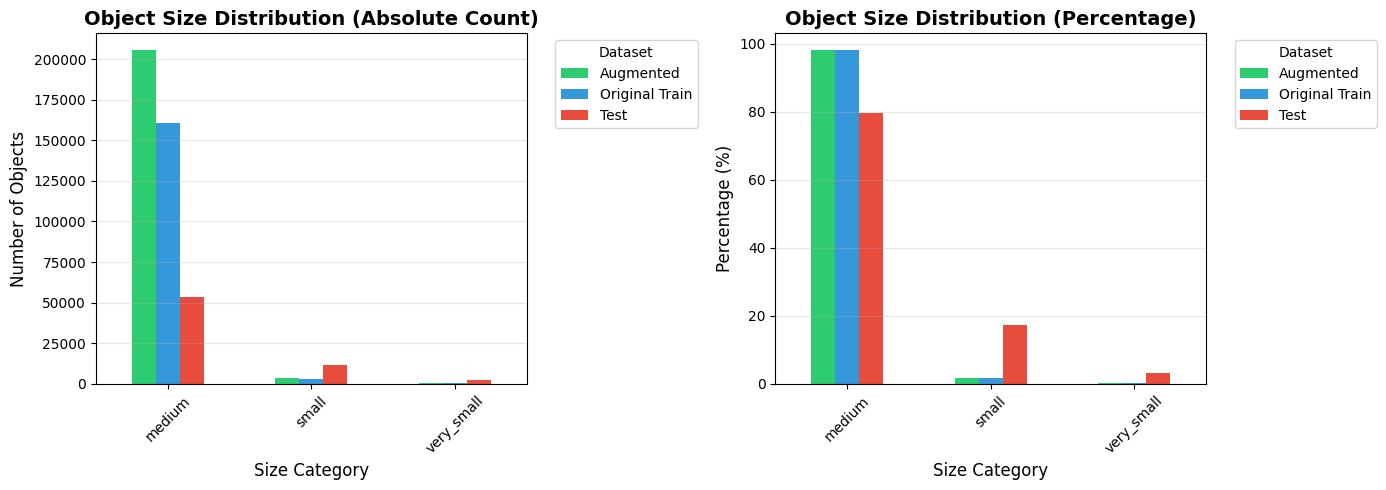

Objects per Image Statistics:
Original Train      :
  Mean: 45.40, Median: 45, Min: 1, Max: 129

Test                :
  Mean: 50.50, Median: 47, Min: 1, Max: 190

Augmented           :
  Mean: 44.65, Median: 44, Min: 1, Max: 129



In [95]:
# Distribution by size category across datasets
size_dist = all_objs.groupby(['dataset', 'size_category']).size().unstack(fill_value=0)
size_dist_pct = size_dist.div(size_dist.sum(axis=1), axis=0) * 100

print('Object Size Distribution Summary:')
print('=' * 70)
print(size_dist)
print()
print('Percentage Distribution:')
print(size_dist_pct.round(2))
print()

# Per-dataset statistics
for dataset in ['Original Train', 'Test', 'Augmented']:
    data = all_objs[all_objs['dataset'] == dataset]
    if len(data) > 0:
        print(f'{dataset:20s}:')
        for cat in ['very_small', 'small', 'medium']:
            count = len(data[data['size_category'] == cat])
            pct = 100.0 * count / len(data)
            print(f'  {cat:15s}: {count:6d} ({pct:6.2f}%)')
        print()

# Visualization: Bar chart comparing distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
size_dist.T.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Object Size Distribution (Absolute Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Size Category')
axes[0].set_ylabel('Number of Objects')
axes[0].legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Percentages
size_dist_pct.T.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_title('Object Size Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Size Category')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Additional analysis: objects per image
print('Objects per Image Statistics:')
print('=' * 70)
for dataset in ['Original Train', 'Test', 'Augmented']:
    data = all_objs[all_objs['dataset'] == dataset]
    objs_per_img = data.groupby('image_name').size()
    if len(objs_per_img) > 0:
        print(f'{dataset:20s}:')
        print(f'  Mean: {objs_per_img.mean():.2f}, Median: {objs_per_img.median():.0f}, '
              f'Min: {objs_per_img.min()}, Max: {objs_per_img.max()}')
        print()

## 5. Extract Image Features for Train, Test, and Augmented Sets

Use a pretrained deep learning model to extract high-dimensional embeddings from images across all three splits.

In [96]:
if torch_available:
    import cv2
    from ultralytics import YOLO

    YOLO_MODEL_PATH = Path('/home/khanh/Projects/DifficultyAgri/finetuned_baseline_model/yolov8s.pt')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if 'yolo_model' not in globals() or 'model' not in globals():
        if YOLO_MODEL_PATH.exists():
            yolo_model = YOLO(str(YOLO_MODEL_PATH))
        else:
            yolo_model = YOLO('yolov8s.pt')
        model = yolo_model.model.to(device).eval()
        for p in model.parameters():
            p.requires_grad = False
    else:
        yolo_model = globals()['yolo_model']
        model = globals()['model']

    FEATURE_LAYER_INDEX = 22  # P5 layer (512 output channels -> averaged to 256D per image)
    IMAGE_SIZE = 1024

    def preprocess_image_for_yolo(image_path: Path, image_size: int = IMAGE_SIZE) -> torch.Tensor | None:
        img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            print(f'Warning: failed to read image {image_path}')
            return None
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
        x = torch.from_numpy(img_resized).float() / 255.0
        return x.permute(2, 0, 1).unsqueeze(0)

    def extract_image_features_yolo(image_path: Path, layer_index: int = FEATURE_LAYER_INDEX) -> np.ndarray:
        """Extract YOLO backbone features from a single image."""
        try:
            x = preprocess_image_for_yolo(image_path)
            if x is None:
                return None

            extracted_feat = None

            def hook(_module, _inputs, output):
                nonlocal extracted_feat
                extracted_feat = output[0] if isinstance(output, (list, tuple)) else output

            handle = model.model[layer_index].register_forward_hook(hook)
            try:
                with torch.no_grad():
                    _ = model(x.to(device))
            finally:
                handle.remove()

            if extracted_feat is None:
                return None

            feat = extracted_feat
            if feat.ndim == 4:
                emb = feat.mean(dim=(2, 3)).squeeze(0)
            elif feat.ndim == 3:
                emb = feat.mean(dim=2).squeeze(0)
            elif feat.ndim == 2:
                emb = feat.squeeze(0)
            else:
                emb = feat.reshape(feat.shape[0], -1).mean(dim=0)

            return emb.detach().cpu().numpy().astype(np.float32)
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return None

    # Filter to only newly created augmented images (aug_*.jpg/png)
    def get_new_augmented_images_only(images_dir: Path):
        """Get YOLO features for only newly created augmented images (aug_*.jpg/png)."""
        features_list = []
        image_names = []
        image_extensions = {'.jpg', '.jpeg', '.png'}

        # Find all aug_*.jpg/png files (newly created synthetic images)
        image_paths = []
        for ext in image_extensions:
            image_paths.extend(sorted([p for p in images_dir.glob(f'aug_*{ext}')]))

        if not image_paths:
            print(f"  WARNING: No aug_* files found in {images_dir}")
            return np.array([]), []

        print(f"Extracting YOLO features from newly augmented images: {len(image_paths)} images...")
        for i, img_path in enumerate(sorted(image_paths), start=1):
            if i % max(1, len(image_paths) // 5) == 0 or i == len(image_paths):
                print(f"  {i}/{len(image_paths)}")
            feat = extract_image_features_yolo(img_path, FEATURE_LAYER_INDEX)
            if feat is not None:
                features_list.append(feat)
                image_names.append(img_path.stem)

        return np.array(features_list), image_names

    # Extract features ONLY for newly created augmented images
    print("\nExtracting image features using YOLO...")
    print("=" * 70)

    aug_features, aug_names = get_new_augmented_images_only(AUG_IMAGES)

    print(f"\nFeatures extracted:")
    print(f"  Newly Augmented Images: {aug_features.shape}")

    # Create dataset with ONLY newly augmented images
    all_features = aug_features
    all_labels = ['Augmented (New)'] * len(aug_features)
    all_image_names = aug_names

    print(f"  Total for analysis:     {all_features.shape}")
else:
    print("PyTorch not available. Skipping feature extraction.")


Extracting image features using YOLO...
Extracting YOLO features from newly augmented images: 1089 images...
  217/1089
  434/1089
  651/1089
  868/1089
  1085/1089
  1089/1089

Features extracted:
  Newly Augmented Images: (1089, 84)
  Total for analysis:     (1089, 84)


## 6. Visualize Feature Space with Dimensionality Reduction

Project high-dimensional embeddings to 2D using PCA for visualization and understand how augmented samples relate to original and test data.

Using YOLO feature layer: P5 -> model.model[21]
Dataset Summary:


,Group,Count
0,Original Train,3655
1,Test,1381
2,New Augmented,1089



Processing Original Train

Processing Test

Processing New Augmented

Extracted embeddings: 6125


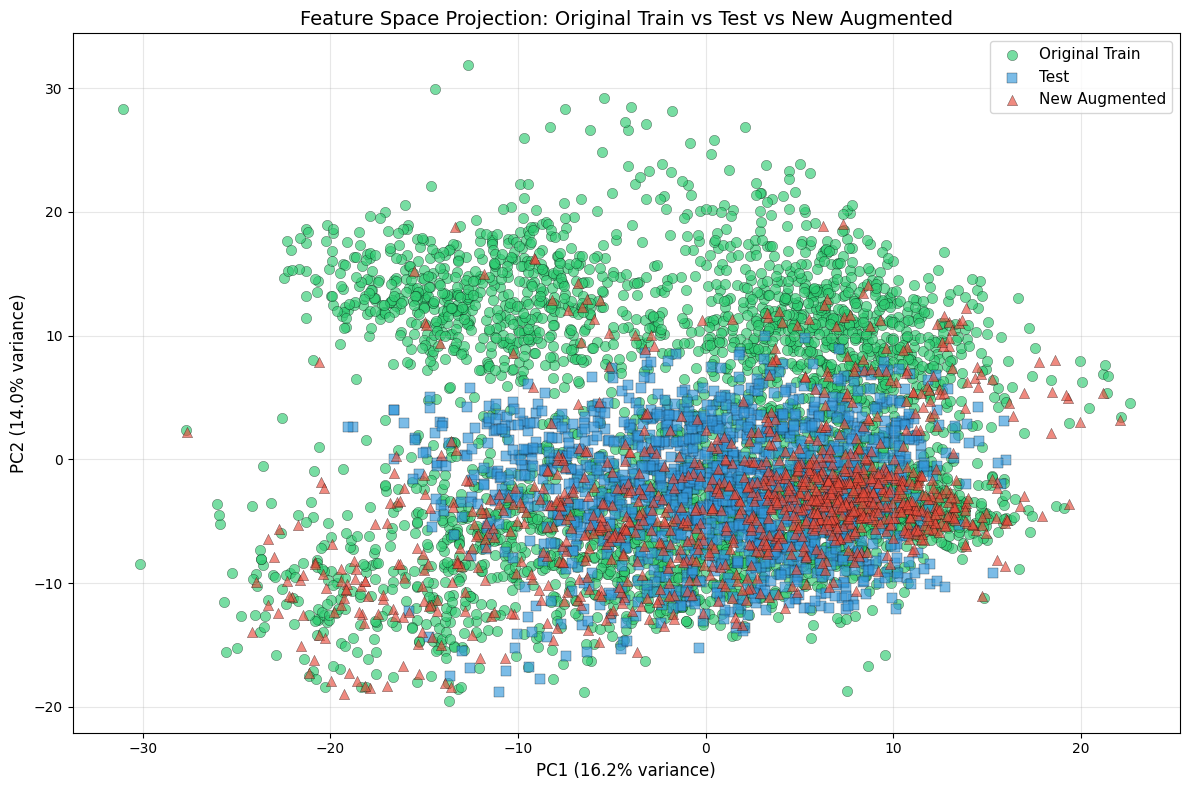


PCA explained variance: 0.302

Group centroids in PCA space:
  Original Train : PC1=-0.7359, PC2=1.8868
  Test           : PC1=0.5409, PC2=-2.3837
  New Augmented  : PC1=1.7841, PC2=-3.3098


In [97]:
# YOLO_MODEL_PATH = Path('/home/khanh/Projects/DifficultyAgri/finetuned_baseline_model/yolov8s.pt')
# device = torch.device('cuda' if torch_available and torch.cuda.is_available() else 'cpu')

if torch_available:
    import cv2
    from ultralytics import YOLO
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    # Rebuild the YOLO detection model if needed
    if 'yolo_model' not in globals() or 'model' not in globals():
        if YOLO_MODEL_PATH.exists():
            yolo_model = YOLO(str(YOLO_MODEL_PATH))
        else:
            yolo_model = YOLO('yolov8s.pt')
        model = yolo_model.model.to(device).eval()
        for p in model.parameters():
            p.requires_grad = False
    else:
        yolo_model = globals()['yolo_model']
        model = globals()['model']

    detect_module = model.model[-1]
    detect_feature_from = list(getattr(detect_module, 'f', []))
    if len(detect_feature_from) >= 3:
        feature_index_map = {
            'P3': int(detect_feature_from[-3]),
            'P4': int(detect_feature_from[-2]),
            'P5': int(detect_feature_from[-1]),
        }
        FEATURE_LEVEL = 'P5'
        FEATURE_LAYER_INDEX = feature_index_map[FEATURE_LEVEL]
    else:
        FEATURE_LEVEL = 'P5'
        FEATURE_LAYER_INDEX = len(model.model) - 2

    print(f'Using YOLO feature layer: {FEATURE_LEVEL} -> model.model[{FEATURE_LAYER_INDEX}]')

    IMAGE_SIZE = 1024
    IMAGE_EXTS = {'.jpg', '.jpeg', '.png'}

    def list_image_paths(directory: Path, pattern: str = '*') -> list[Path]:
        if not directory.exists():
            return []
        return sorted(
            [p for p in directory.glob(pattern) if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
        )

    def preprocess_image_for_yolo(image_path: Path, image_size: int = IMAGE_SIZE) -> torch.Tensor | None:
        img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            print(f'Warning: failed to read image {image_path}')
            return None
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
        x = torch.from_numpy(img_resized).float() / 255.0
        return x.permute(2, 0, 1).unsqueeze(0)

    def extract_image_embedding(image_path: Path, layer_index: int) -> np.ndarray | None:
        captured = {}

        def hook_fn(_module, _inputs, output):
            if isinstance(output, (tuple, list)):
                output = output[0]
            captured['feat'] = output

        handle = model.model[layer_index].register_forward_hook(hook_fn)
        try:
            x = preprocess_image_for_yolo(image_path)
            if x is None:
                return None
            x = x.to(device)
            with torch.no_grad():
                _ = model(x)
            feat = captured.get('feat')
            if feat is None:
                return None
            if feat.ndim == 4:
                emb = feat.mean(dim=(2, 3)).squeeze(0)
            elif feat.ndim == 3:
                emb = feat.mean(dim=2).squeeze(0)
            elif feat.ndim == 2:
                emb = feat.squeeze(0)
            else:
                emb = feat.reshape(feat.shape[0], -1).mean(dim=0)
            return emb.detach().cpu().numpy().astype(np.float32)
        except Exception as e:
            print(f'Error processing {image_path}: {e}')
            return None
        finally:
            handle.remove()

    def sample_paths(paths: list[Path], max_count: int | None = None) -> list[Path]:
        if max_count is None or len(paths) <= max_count:
            return paths
        return paths[:max_count]

    def extract_group_features(paths: list[Path], group_name: str) -> tuple[np.ndarray, list[str]]:
        features = []
        names = []
        print(f'Extracting features for {group_name}: {len(paths)} images')
        for i, image_path in enumerate(paths, start=1):
            if i % max(1, len(paths) // 5) == 0 or i == len(paths):
                print(f'  {i}/{len(paths)}')
            emb = extract_image_embedding(image_path, FEATURE_LAYER_INDEX)
            if emb is not None:
                features.append(emb)
                names.append(image_path.stem)
        return np.asarray(features, dtype=np.float32), names

    original_paths = list_image_paths(ORIG_TRAIN_IMAGES, '*.jpg') + list_image_paths(ORIG_TRAIN_IMAGES, '*.jpeg') + list_image_paths(ORIG_TRAIN_IMAGES, '*.png')
    test_paths = list_image_paths(TEST_IMAGES, '*.jpg') + list_image_paths(TEST_IMAGES, '*.jpeg') + list_image_paths(TEST_IMAGES, '*.png')
    new_paths = list_image_paths(AUG_IMAGES, 'aug_*.jpg')
    if not new_paths:
        new_paths = list_image_paths(AUG_IMAGES, 'aug_*.png')

    group_to_paths = {
        'Original Train': original_paths,
        'Test': test_paths,
        'New Augmented': new_paths,
    }

    counts_df = pd.DataFrame({
        'Group': list(group_to_paths.keys()),
        'Count': [len(v) for v in group_to_paths.values()],
    })
    print('Dataset Summary:')
    display(counts_df)

    if any(len(v) == 0 for v in group_to_paths.values()):
        raise RuntimeError('At least one group has 0 images. Check the input paths and the aug_*.jpg files.')

    records = []
    for group_name, paths in group_to_paths.items():
        print(f'\nProcessing {group_name}')
        for image_path in sample_paths(paths, None):
            emb = extract_image_embedding(image_path, FEATURE_LAYER_INDEX)
            if emb is not None:
                records.append({'group': group_name, 'image_path': str(image_path), 'embedding': emb})

    print(f'\nExtracted embeddings: {len(records)}')
    if not records:
        raise RuntimeError('No embeddings extracted.')

    meta_df = pd.DataFrame([{'group': r['group'], 'image_path': r['image_path']} for r in records])
    X = np.stack([r['embedding'] for r in records], axis=0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=2, random_state=123)
    X_2d = pca.fit_transform(X_scaled)

    plot_df = meta_df.copy()
    plot_df['PC1'] = X_2d[:, 0]
    plot_df['PC2'] = X_2d[:, 1]

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = {'Original Train': '#2ecc71', 'Test': '#3498db', 'New Augmented': '#e74c3c'}
    markers = {'Original Train': 'o', 'Test': 's', 'New Augmented': '^'}
    for group in ['Original Train', 'Test', 'New Augmented']:
        mask = plot_df['group'] == group
        ax.scatter(
            plot_df[mask]['PC1'],
            plot_df[mask]['PC2'],
            label=group,
            alpha=0.65,
            s=55,
            marker=markers[group],
            c=colors[group],
            edgecolors='black',
            linewidth=0.3,
        )

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
    ax.set_title('Feature Space Projection: Original Train vs Test vs New Augmented')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('\nPCA explained variance:', f'{pca.explained_variance_ratio_.sum():.3f}')
    print('\nGroup centroids in PCA space:')
    for group in ['Original Train', 'Test', 'New Augmented']:
        mask = plot_df['group'] == group
        centroid = plot_df[mask][['PC1', 'PC2']].mean().values
        print(f'  {group:15s}: PC1={centroid[0]:.4f}, PC2={centroid[1]:.4f}')
else:
    print('PyTorch not available. Skipping feature extraction.')